# Diabetes Prediction using Machine Learning
## Intership Project
Name: Kaviya M

## import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

## Load Dataset

In [5]:
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Dataset information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Statistical summary

In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Missing Values

In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## Dataset Shape

In [12]:
print("Dataset Shape:",df.shape)

Dataset Shape: (768, 9)


## Data Types of Features 

In [13]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

## Histogram of Dataset Features

A histogram is used to visualize the distribution of numerical variables in the dataset. It helps identify how the values are spread, whether the data is normally distributed, and if any feature is skewed or contains extreme values. Understanding the distribution of features is important before building a machine learning model.

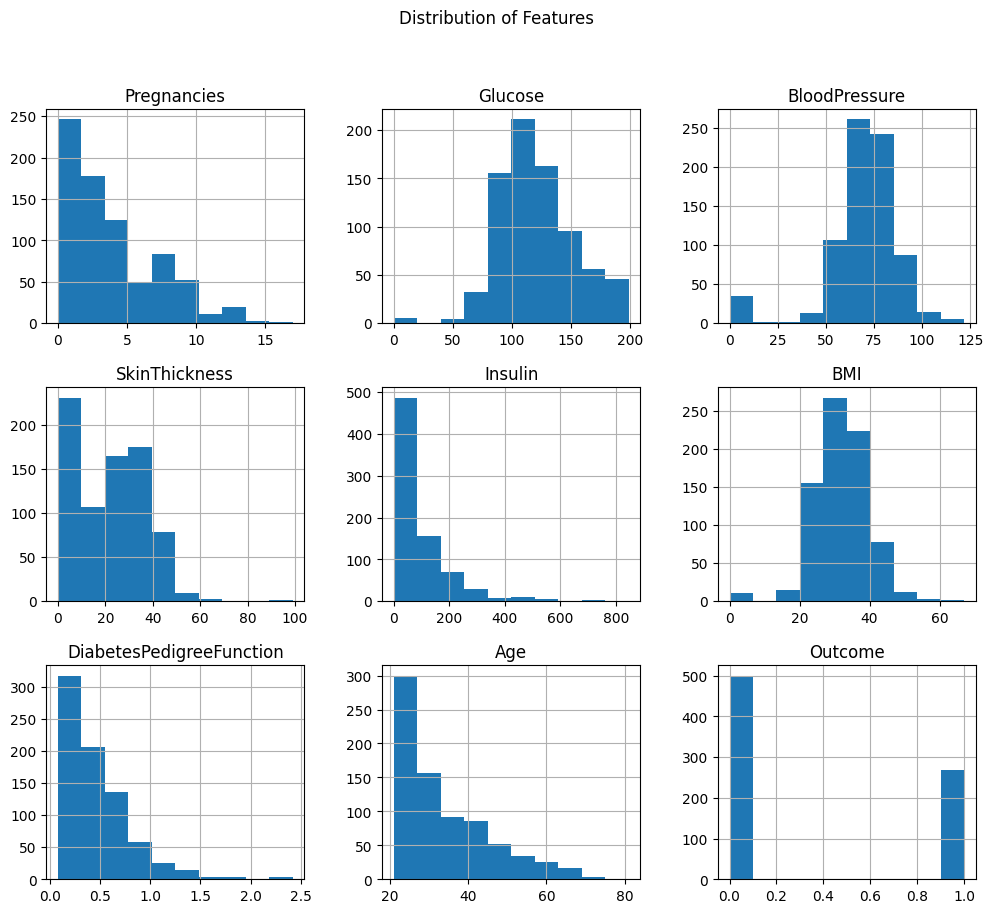

In [16]:
df.hist(figsize=(12,10))
plt.suptitle("Distribution of Features")
plt.show()

### Observation

- The **Pregnancies** feature is right-skewed, indicating that most patients have fewer pregnancies.
- **Glucose** values are concentrated around the middle range, with a few high values.
- **Blood Pressure** follows an approximately normal distribution.
- **Skin Thickness** contains many low values and shows slight skewness.
- **Insulin** is highly right-skewed, indicating the presence of extreme values (outliers).
- **BMI** is approximately normally distributed, with most values between 20 and 40.
- **Diabetes Pedigree Function** is right-skewed, with most values below 1.
- **Age** is right-skewed, showing that most patients are younger than 40 years.
- The **Outcome** variable contains two classes (0 = Non-Diabetic, 1 = Diabetic), with more non-diabetic cases than diabetic cases.

Overall, the histograms provide a clear understanding of the distribution of each feature and help identify skewed variables that may require preprocessing before model training.

## Box Plot for Outlier Detection

A box plot is used to visualize the spread of numerical data and identify outliers. It displays the median, quartiles, and the overall distribution of each feature. Data points that lie outside the whiskers are considered outliers. Detecting outliers is an important step in data preprocessing because they can influence the performance of machine learning models.


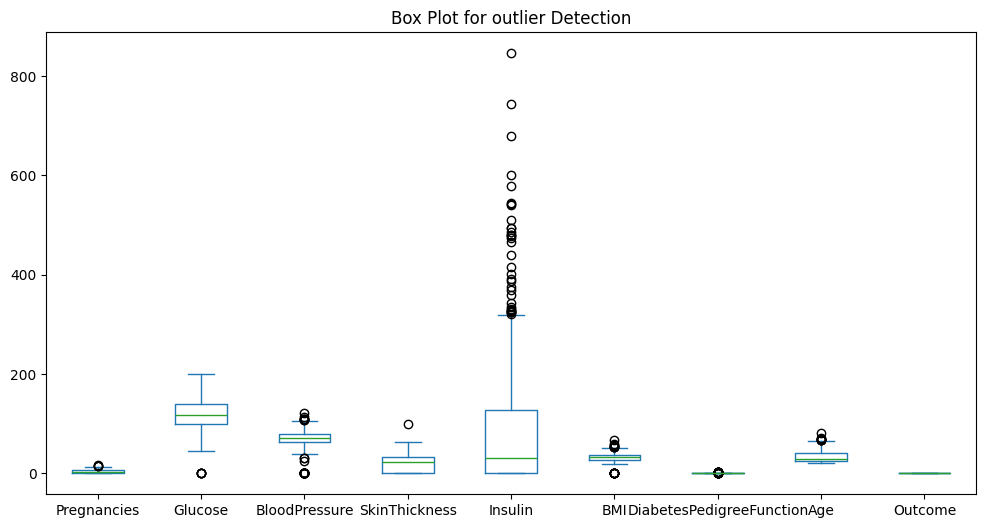

In [17]:
df.plot(kind='box',figsize=(12,6))
plt.title("Box Plot for outlier Detection")
plt.show()

### Observation

- The box plot shows the distribution of all numerical features in the diabetes dataset.
- The **Insulin** feature contains a large number of outliers, indicating a highly skewed distribution.
- **SkinThickness**, **BMI**, **Age**, **BloodPressure**, and **Glucose** also contain a few outliers.
- **Pregnancies** and **DiabetesPedigreeFunction** show only a small number of outliers.
- The **Outcome** variable is a binary feature (0 and 1), so it does not show significant variation.
- Outliers are common in medical datasets and may represent genuine patient measurements rather than errors. Therefore, they should be carefully examined before deciding whether to remove or retain them.

Overall, the box plot helps identify features with extreme values and provides valuable insights for data preprocessing before model training.

## Correlation Heatmap

A correlation heatmap is used to measure the relationship between numerical features in the dataset. Correlation values range from -1 to +1.

- A value close to **+1** indicates a strong positive relationship.
- A value close to **-1** indicates a strong negative relationship.
- A value close to **0** indicates little or no relationship.

This analysis helps identify the features that are most strongly associated with the target variable (Outcome).

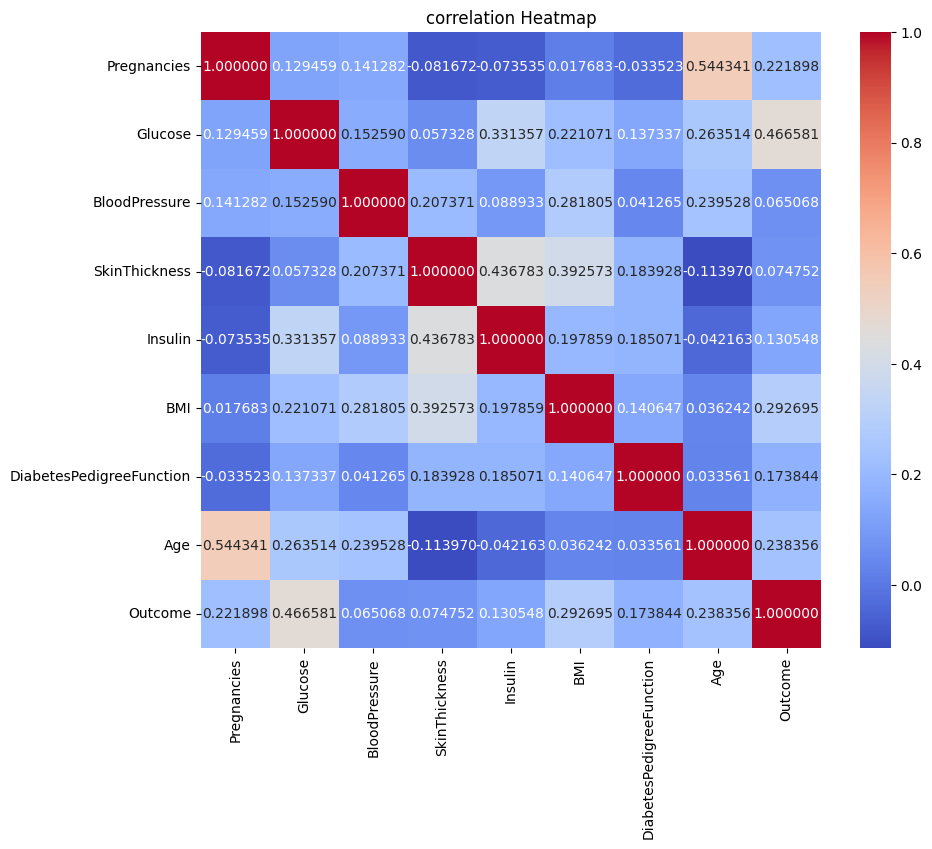

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
corr=df.corr(numeric_only=True) # Calculate Correlation matrix
plt.figure(figsize=(10,8)) # plot heatmap
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='2f')
plt.title("correlation Heatmap")
plt.show()

### Observation

- The heatmap shows the correlation between all numerical features in the diabetes dataset.
- **Glucose** has the highest positive correlation with **Outcome** (approximately 0.47), indicating that higher glucose levels are strongly associated with diabetes.
- **BMI** also has a moderate positive correlation with **Outcome**, suggesting that body mass index influences diabetes risk.
- **Age** and **Pregnancies** have a weak positive correlation with the target variable.
- **BloodPressure**, **SkinThickness**, **Insulin**, and **DiabetesPedigreeFunction** have relatively weak correlations with the outcome.
- There are no extremely high correlations between predictor variables, indicating that multicollinearity is low.

Overall, the heatmap suggests that **Glucose** is the most important feature for predicting diabetes in this dataset.

## Splitting the Dataset into Training and Testing Sets

Before training a machine learning model, the dataset is divided into two parts: a training set and a testing set.

- The **training set** is used to train the model and learn patterns from the data.
- The **testing set** is used to evaluate the model's performance on unseen data.

In this project, 80% of the data is used for training and 20% is used for testing.

In [23]:
# Split features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (614, 8)
Testing data shape: (154, 8)


### Observation

- The dataset was successfully divided into training and testing sets.
- The training set contains **614 records** with **8 input features**.
- The testing set contains **154 records** with **8 input features**.
- This split allows the model to learn from the training data and evaluate its performance on unseen testing data.
- Using separate training and testing datasets helps reduce overfitting and provides a more reliable estimate of model performance.

## Decision Tree Model Training

In this step, a Decision Tree classifier is created and trained using the training dataset. The `DecisionTreeClassifier` from Scikit-learn is initialized with a fixed random state (`random_state=42`) to ensure reproducible results. The model is then fitted to the training data using the `fit()` method, allowing it to learn patterns from the input features and target labels. After successful training, a confirmation message is displayed.

In [25]:
# Create the Decision Tree model
model = DecisionTreeClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


### Observation

- The Decision Tree model was successfully created and trained using the training dataset.
- During training, the model learned the relationship between the input features (Pregnancies, Glucose, Blood Pressure, Skin Thickness, Insulin, BMI, Diabetes Pedigree Function, and Age) and the target variable (Outcome).
- The trained model is now ready to make predictions on the testing dataset.
- This is an important step in the machine learning workflow because the model uses the learned patterns to classify whether a patient is diabetic or non-diabetic.

## Making Predictions on the Test Dataset

After training the Decision Tree model, the next step is to make predictions on the testing dataset. The `predict()` method uses the learned patterns from the training data to classify each patient as either diabetic or non-diabetic.

- **0** represents **Non-Diabetic**.
- **1** represents **Diabetic**.

The predicted values will be compared with the actual values to evaluate the performance of the model.

In [26]:
# Make predictions on the test dataset
y_pred = model.predict(X_test)

print("Predicted values:")
print(y_pred)

Predicted values:
[1 0 0 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 1 1 1 1 0 1 1
 0 0 1 0 1 1 1 0 1 1 0 0 1 0 1 1 0 0 0 0 0 0 1 1 0 1 0 0 0 0 1 0 1 1 0 0 0
 0 1 0 0 0 0 1 0 0 1 1 1 1 1 1 0 0 0 0 1 1 0 1 0 1 0 1 0 1 0 1 0 0 1 0 1 0
 0 0 1 1 1 1 0 0 1 0 0 0 0 0 1 1 1 1 1 1 1 0 0 1 1 0 1 1 0 0 0 0 0 0 0 0 0
 0 1 0 1 0 0]


### Observation

- The trained Decision Tree model successfully generated predictions for all patients in the testing dataset.
- Each predicted value is either **0** (Non-Diabetic) or **1** (Diabetic).
- These predictions represent the model's classification based on the input features.
- The predicted values will be compared with the actual outcomes to calculate the model's accuracy and evaluate its overall performance.
- This step is essential because it helps determine how well the model performs on unseen data.

## Model Accuracy Evaluation

After making predictions on the testing dataset, the next step is to evaluate the performance of the Decision Tree model. Accuracy is one of the most commonly used evaluation metrics for classification problems.

Accuracy is calculated as:

**Accuracy = (Number of Correct Predictions) / (Total Number of Predictions)**

A higher accuracy indicates that the model is making more correct predictions.

In [27]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7467532467532467


### Observation

- The Decision Tree model achieved an accuracy of **74.68%** on the testing dataset.
- This means the model correctly predicted the diabetes status for approximately **75 out of every 100 patients**.
- The obtained accuracy indicates that the model performs reasonably well in classifying diabetic and non-diabetic patients.
- Further improvements in accuracy may be achieved through feature engineering, hyperparameter tuning, or by using more advanced machine learning algorithms.

## Confusion Matrix

A Confusion Matrix is used to evaluate the performance of a classification model by comparing the actual labels with the predicted labels. It provides a detailed summary of correct and incorrect predictions made by the model.

The confusion matrix consists of:
- **True Negative (TN):** Correctly predicted non-diabetic patients.
- **False Positive (FP):** Non-diabetic patients incorrectly predicted as diabetic.
- **False Negative (FN):** Diabetic patients incorrectly predicted as non-diabetic.
- **True Positive (TP):** Correctly predicted diabetic patients.

This visualization helps in understanding the strengths and weaknesses of the Decision Tree classifier.

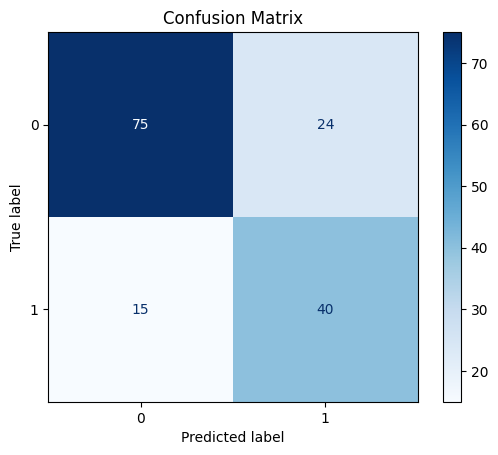

In [28]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

### Observation

- The confusion matrix shows that the Decision Tree model correctly classified **75 non-diabetic patients (True Negatives)** and **40 diabetic patients (True Positives)**.
- It incorrectly classified **24 non-diabetic patients as diabetic (False Positives)** and **15 diabetic patients as non-diabetic (False Negatives)**.
- The model produced more correct predictions than incorrect ones, resulting in an overall accuracy of **74.68%**.
- The confusion matrix provides a detailed evaluation of the model's classification performance and helps identify areas where the model can be improved.

## Classification Report

A Classification Report is used to evaluate the performance of a classification model in more detail. It provides important metrics such as Precision, Recall, F1-Score, and Support for each class.

These metrics help us understand how well the Decision Tree model classifies diabetic and non-diabetic patients beyond overall accuracy.

In [29]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(y_test, y_pred)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.76      0.79        99
           1       0.62      0.73      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



### Observation

- The classification report provides a detailed evaluation of the Decision Tree model using Precision, Recall, F1-Score, and Support.
- For the **Non-Diabetic (Class 0)** category, the model achieved a **Precision of 0.83**, **Recall of 0.76**, and an **F1-Score of 0.79**, indicating good performance.
- For the **Diabetic (Class 1)** category, the model achieved a **Precision of 0.62**, **Recall of 0.73**, and an **F1-Score of 0.67**, showing that it correctly identified many diabetic patients but still has room for improvement.
- The overall model achieved an **accuracy of 75%**, demonstrating satisfactory performance in predicting diabetes.
- The weighted average F1-score of **0.75** indicates balanced overall classification performance across both classes.

# Conclusion

* In this project, a Decision Tree Classifier was developed to predict whether a patient has diabetes based on medical attributes. 
* The dataset was preprocessed, split into training and testing sets, and used to train the model.
* The trained model achieved an accuracy of **74.68%**, demonstrating satisfactory performance in classifying diabetic and non-diabetic patients.
*  The Confusion Matrix and Classification Report showed that the model made more correct predictions than incorrect ones, although there is scope for improvement. Overall, the Decision Tree algorithm proved to be an effective and easy-to-understand machine learning technique for diabetes prediction.

# References

1. UCI Machine Learning Repository - Pima Indians Diabetes Dataset.
2. Scikit-learn Documentation: https://scikit-learn.org/
3. Pandas Documentation: https://pandas.pydata.org/
4. NumPy Documentation: https://numpy.org/
5. Matplotlib Documentation: https://matplotlib.org/